['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
<class 'pandas.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       7861 non-null   int64  
 1   C       7861 non-null   int64  
 2   B       7861 non-null   int64  
 3   A       7861 non-null   int64  
 4   Ia      7861 non-null   float64
 5   Ib      7861 non-null   float64
 6   Ic      7861 non-null   float64
 7   Va      7861 non-null   float64
 8   Vb      7861 non-null   float64
 9   Vc      7861 non-null   float64
dtypes: float64(6), int64(4)
memory usage: 614.3 KB
G     0
C     0
B     0
A     0
Ia    0
Ib    0
Ic    0
Va    0
Vb    0
Vc    0
dtype: int64
fault_type
0000    2365
1011    1134
1111    1133
1001    1129
0111    1096
0110    1004
Name: count, dtype: int64


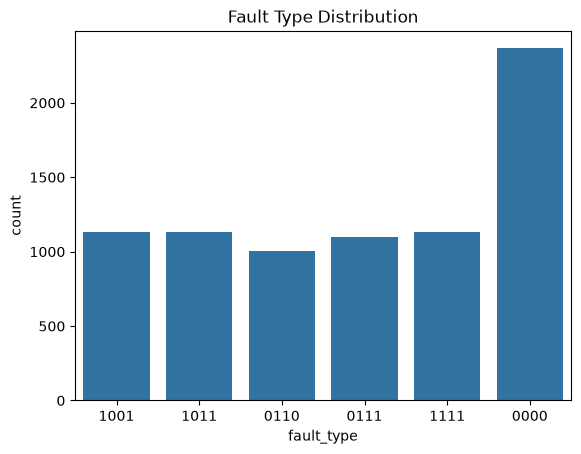

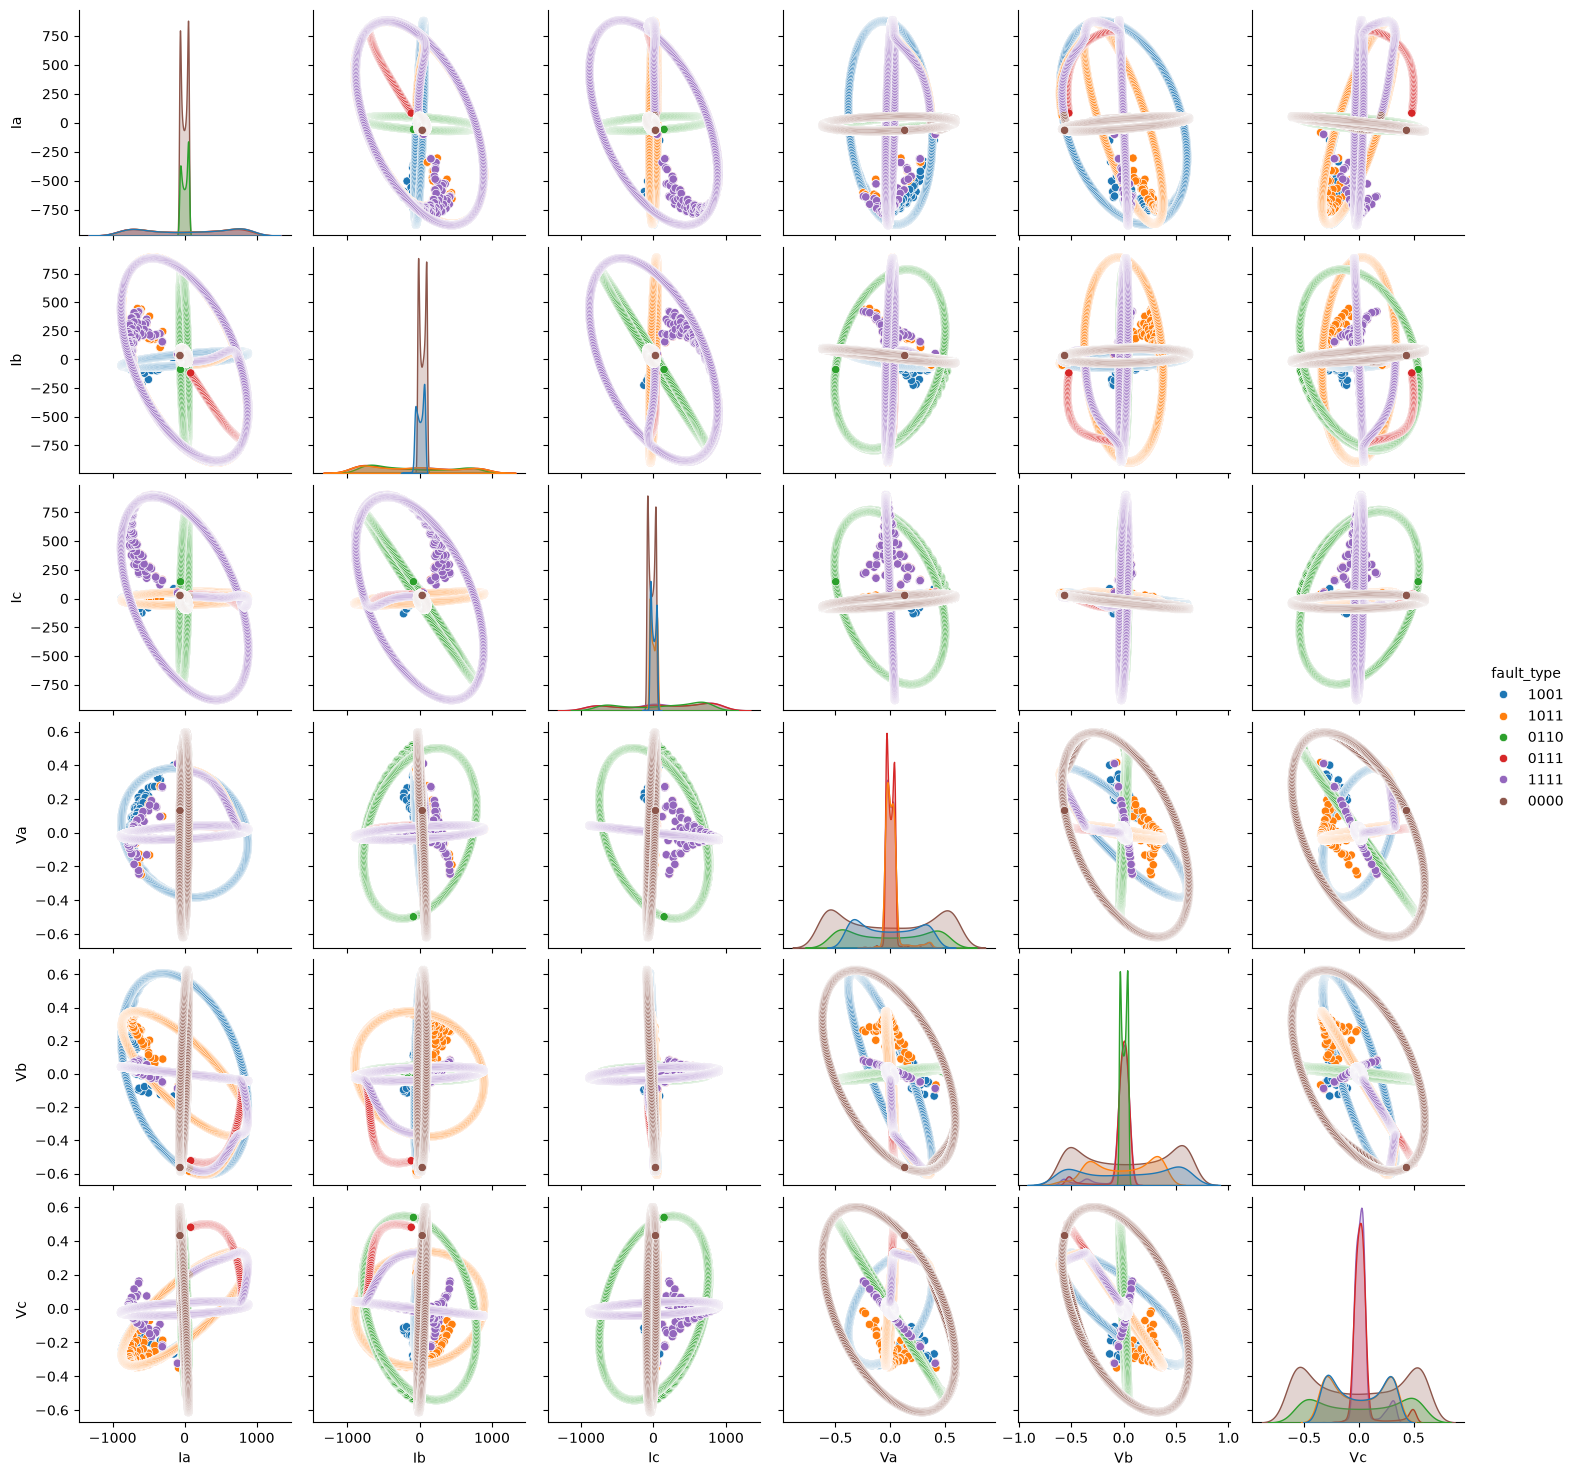


--- Classification report for G ---
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       882
           1       0.88      0.86      0.87       691

    accuracy                           0.88      1573
   macro avg       0.88      0.88      0.88      1573
weighted avg       0.88      0.88      0.88      1573


--- Classification report for C ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       962
           1       1.00      1.00      1.00       611

    accuracy                           1.00      1573
   macro avg       1.00      1.00      1.00      1573
weighted avg       1.00      1.00      1.00      1573


--- Classification report for B ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       724
           1       1.00      1.00      1.00       849

    accuracy                           1.00      1573
   macro avg     

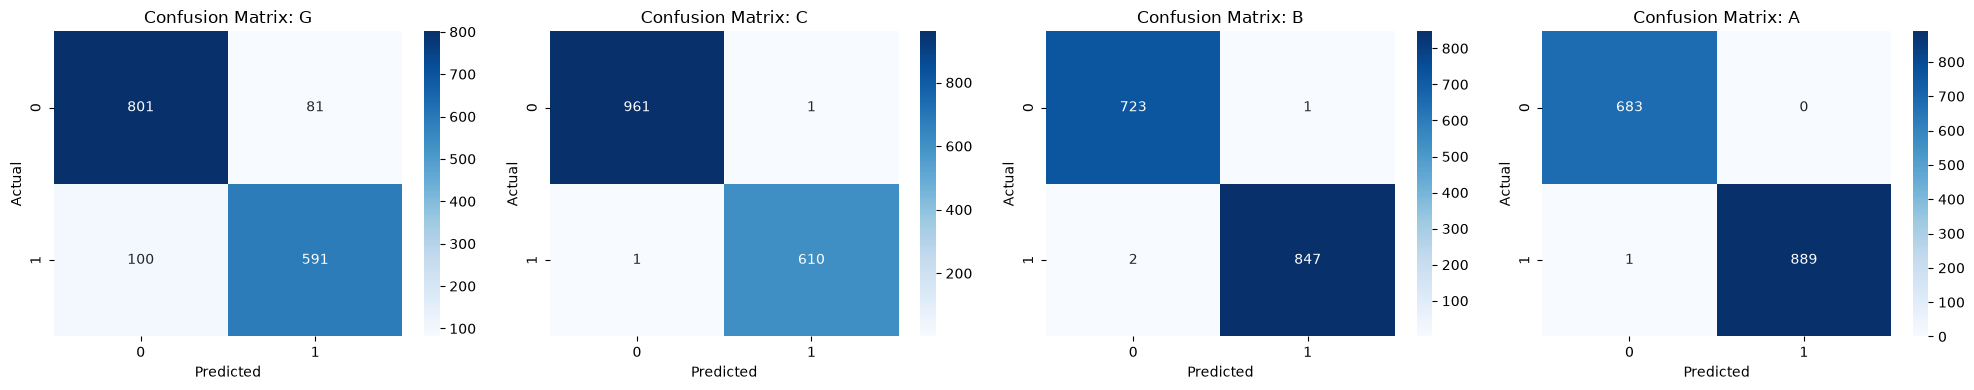

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('classData.csv')
print(df.columns.tolist())

# 2. Explore
df.head()
df.info()
df.describe()
print(df.isnull().sum())

# 3. Combine G,C,B,A into one readable label just for visualization
df['fault_type'] = (
    df['G'].astype(str) + df['C'].astype(str) +
    df['B'].astype(str) + df['A'].astype(str)
)
print(df['fault_type'].value_counts())

sns.countplot(x='fault_type', data=df)
plt.title('Fault Type Distribution')
plt.show()

sns.pairplot(df, hue='fault_type', vars=['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc'])
plt.show()

# 4. Prepare features (X) and multi-label target (y)
X = df.drop(['G', 'C', 'B', 'A', 'fault_type'], axis=1)
y = df[['G', 'C', 'B', 'A']]   # 4 binary targets at once

# 5. Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Multi-output Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

base_model = RandomForestClassifier(random_state=42, n_estimators=100)
model = MultiOutputClassifier(base_model)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 7. Evaluate — report per output column (G, C, B, A)
from sklearn.metrics import classification_report, accuracy_score

y_pred_df = pd.DataFrame(y_pred, columns=['G', 'C', 'B', 'A'])

for col in ['G', 'C', 'B', 'A']:
    print(f"\n--- Classification report for {col} ---")
    print(classification_report(y_test[col], y_pred_df[col]))

# 8. Overall exact-match accuracy (all 4 labels must match)
exact_match_acc = accuracy_score(y_test, y_pred)
print(f"\nExact match accuracy (all 4 labels correct): {exact_match_acc:.4f}")

# 9. Confusion matrix for each output (optional, visual)
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(['G', 'C', 'B', 'A']):
    cm = confusion_matrix(y_test[col], y_pred_df[col])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {col}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [14]:
import numpy as np

def detect_fault(sensor_reading):
    """
    Takes a live sensor reading and predicts fault status.

    Parameters
    ----------
    sensor_reading : array-like
        A single reading in the order: [Ia, Ib, Ic, Va, Vb, Vc]

    Returns
    -------
    dict with prediction details
    """
    # Reshape to 2D since sklearn expects (n_samples, n_features)
    reading = np.array(sensor_reading).reshape(1, -1)

    # Predict G, C, B, A all at once
    prediction = model.predict(reading)[0]   # e.g. array([1, 0, 0, 1])
    g, c, b, a = prediction

    # Build a human-readable fault description
    phases_involved = []
    if a == 1:
        phases_involved.append('A')
    if b == 1:
        phases_involved.append('B')
    if c == 1:
        phases_involved.append('C')
    if g == 1:
        phases_involved.append('G')

    is_fault = (g == 1 or c == 1 or b == 1 or a == 1)

    if is_fault:
        fault_label = '-'.join(phases_involved)
        print(f"⚠️  ALERT: Fault detected! Type: {fault_label}")
        print(f"   Raw reading -> Ia={sensor_reading[0]:.2f}, Ib={sensor_reading[1]:.2f}, "
              f"Ic={sensor_reading[2]:.2f}, Va={sensor_reading[3]:.3f}, "
              f"Vb={sensor_reading[4]:.3f}, Vc={sensor_reading[5]:.3f}")
    else:
        print("✅ System normal — no fault detected.")

    return {
        'fault_detected': is_fault,
        'G': int(g), 'C': int(c), 'B': int(b), 'A': int(a),
        'fault_type': '-'.join(phases_involved) if is_fault else 'None'
    }


# ---- Example usage: simulate live sensor readings ----

# Take one real test row to simulate a "live" reading
sample_reading = X_test.iloc[0].values
result = detect_fault(sample_reading)
print(result)

# Simulate a stream of multiple readings (like sensors sending data every second)
print("\n--- Simulating live stream ---")
for i in range(5):
    live_reading = X_test.iloc[i].values
    print(f"\nReading {i+1}:")
    detect_fault(live_reading)

✅ System normal — no fault detected.
{'fault_detected': np.False_, 'G': 0, 'C': 0, 'B': 0, 'A': 0, 'fault_type': 'None'}

--- Simulating live stream ---

Reading 1:
✅ System normal — no fault detected.

Reading 2:
⚠️  ALERT: Fault detected! Type: A-B-G
   Raw reading -> Ia=711.67, Ib=70.72, Ic=43.42, Va=0.038, Vb=-0.376, Vc=0.338

Reading 3:
⚠️  ALERT: Fault detected! Type: A-G
   Raw reading -> Ia=688.79, Ib=70.62, Ic=-29.55, Va=-0.281, Vb=0.188, Vc=0.093

Reading 4:
⚠️  ALERT: Fault detected! Type: A-B-G
   Raw reading -> Ia=-531.63, Ib=-329.34, Ic=-52.71, Va=-0.042, Vb=0.366, Vc=-0.324

Reading 5:
✅ System normal — no fault detected.


c:\Users\mishr\Desktop\fault detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\mishr\Desktop\fault detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\mishr\Desktop\fault detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\mishr\Desktop\fault detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\mishr\Desktop\fault detection\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does